In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.utils import resample
from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

In [3]:
X, y = make_classification(n_classes=2,
                           weights=[0.95, 0.05],
                           n_features=4,
                           n_samples=1000,
                           random_state=42)

df = pd.DataFrame(X, columns=['feature_1',
                              'feature_2',
                              'feature_3',
                              'feature_4'])

In [4]:
df['class'] = y

In [5]:
df.head()

,feature_1,feature_2,feature_3,feature_4,class
0,-1.194848,1.138331,-1.482079,1.025358,0
1,0.290131,0.317681,-0.996519,0.477009,0
2,-0.522737,-0.121434,0.765888,-0.308384,0
3,1.738138,-0.188065,-1.195371,0.302161,0
4,1.828884,-0.289261,-1.049151,0.206271,0


In [6]:
df['class'].value_counts()

class
0    945
1     55
Name: count, dtype: int64

In [7]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_log, y_train_log)

# Predict on the test set
y_pred = log_reg.predict(X_test_log)

# Calculate evaluation metrics
precision = precision_score(y_test_log, y_pred)
recall = recall_score(y_test_log, y_pred)
f1 = f1_score(y_test_log, y_pred)
roc_auc = roc_auc_score(y_test_log, y_pred)

# Print the evaluation metrics
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)

Precision: 1.0
Recall: 0.21428571428571427
F1 Score: 0.35294117647058826
ROC AUC Score: 0.6071428571428571


In [8]:
df_major = df[df['class'] == 0]
df_minor = df[df['class'] == 1]

In [9]:
df_major.shape

(945, 5)

In [10]:
df_minor.shape

(55, 5)

### Class Imbalance handling teshnique

#### Class Weights

In [11]:
X_train_cw, X_test_cw, y_train_cw, y_test_cw = train_test_split(X, y, random_state=42, test_size=0.2)

In [12]:
def calculate_class_weights(y_train):
    unique_classes, class_counts = np.unique(y_train, return_counts=True)
    print(f"UniqueClass: {unique_classes}, classCounts: {class_counts}")
    total_samples = len(y_train)
    print(f"Total Samples {total_samples}")
    class_weights = {}
    for class_label, class_count in zip(unique_classes, class_counts):
        class_weight = total_samples / (2.0 * class_count)  # We have used n_classes = 2, because we have 2 classes - 0 and 1
        class_weights[class_label] = class_weight
    return class_weights

In [13]:
class_weights = calculate_class_weights(y_train_cw)
print(class_weights)

UniqueClass: [0 1], classCounts: [759  41]
Total Samples 800
{np.int64(0): np.float64(0.5270092226613966), np.int64(1): np.float64(9.75609756097561)}


In [14]:
log_reg_weighted = LogisticRegression(class_weight = class_weights)
log_reg_weighted.fit(X_train_cw, y_train_cw)

# Predict on the test set
y_pred_weighted = log_reg_weighted.predict(X_test_cw)

# Calculate evaluation metrics
precision_weighted = precision_score(y_test_cw, y_pred_weighted)
recall_weighted = recall_score(y_test_cw, y_pred_weighted)
f1_weighted = f1_score(y_test_cw, y_pred_weighted)
roc_auc_weighted = roc_auc_score(y_test_cw, y_pred_weighted)

print("Precision (weighted):", precision_weighted)
print("Recall (weighted):", recall_weighted)
print("F1 Score (weighted):", f1_weighted)
print("ROC AUC Score (weighted):", roc_auc_weighted)

Precision (weighted): 0.37037037037037035
Recall (weighted): 0.7142857142857143
F1 Score (weighted): 0.4878048780487805
ROC AUC Score (weighted): 0.8114439324116745


#### Synthetic Minority Oversampling Technique (SMOTE)

**It is an Over-Sampling technique**

- SMOTE is used to generate artificial/synthetic samples for the minority class.

- This technique works by randomly choosing a sample from a minority class and determining K-Nearest Neighbors for this sample, then the artificial sample is added between the picked sample and its neighbors. This function is present in imblearn module.

In [15]:
t = [(d) for d in y if d==0]
s = [(d) for d in y if d==1]
print('class 0: ',len(t))
print('class 1: ',len(s))

class 0:  945
class 1:  55


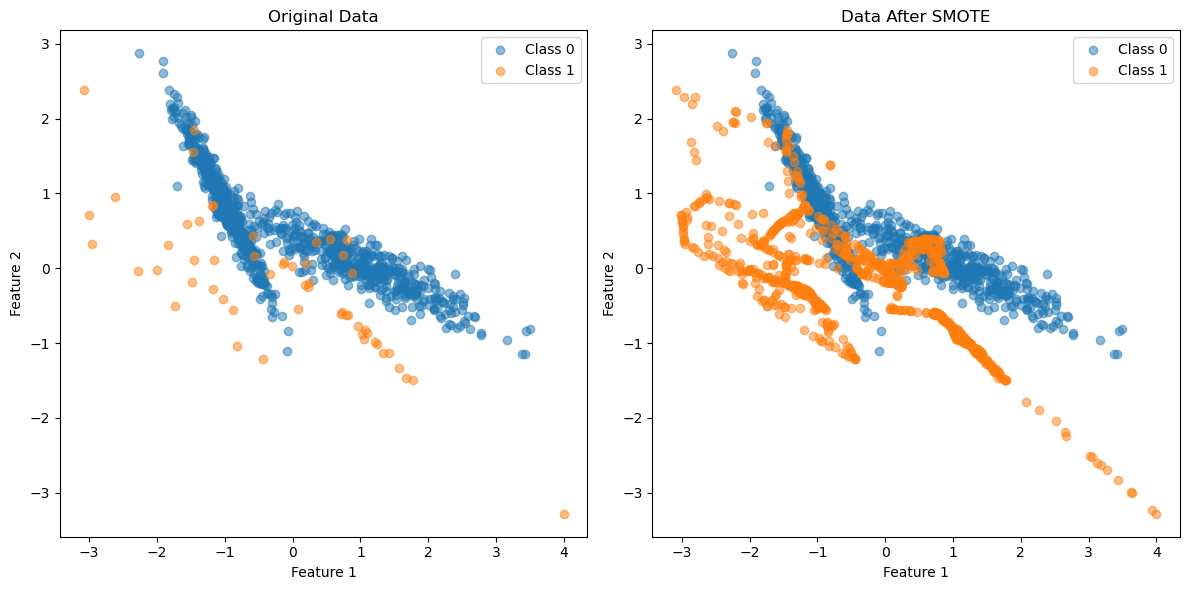

In [16]:
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X, y)

plt.figure(figsize=(12, 6))

# Plot original data
plt.subplot(1, 2, 1)
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Class 0', alpha=0.5)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Class 1', alpha=0.5)
plt.title('Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Plot data after SMOTE
plt.subplot(1, 2, 2)
plt.scatter(X_smote[y_smote == 0][:, 0], X_smote[y_smote == 0][:, 1], label='Class 0', alpha=0.5)
plt.scatter(X_smote[y_smote == 1][:, 0], X_smote[y_smote == 1][:, 1], label='Class 1', alpha=0.5)
plt.title('Data After SMOTE')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.tight_layout()

In [17]:
t = [(d) for d in y_smote if d==0]
s = [(d) for d in y_smote if d==1]
print('After Over-Sampling: ')
print('Samples in class 0: ',len(t))
print('Samples in class 1: ',len(s))

After Over-Sampling: 
Samples in class 0:  945
Samples in class 1:  945


In [18]:
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42)

# Train logistic regression model
log_reg_smote = LogisticRegression()
log_reg_smote.fit(X_train_smote, y_train_smote)

# Predict on the test set
y_pred_smote = log_reg_smote.predict(X_test_smote)

# Calculate evaluation metrics
precision_smote = precision_score(y_test_smote, y_pred_smote)
recall_smote = recall_score(y_test_smote, y_pred_smote)
f1_smote = f1_score(y_test_smote, y_pred_smote)
roc_auc_smote = roc_auc_score(y_test_smote, y_pred_smote)

# Print the evaluation metrics
print("Precision (SMOTE):", precision_smote)
print("Recall (SMOTE):", recall_smote)
print("F1 Score (SMOTE):", f1_smote)
print("ROC AUC Score (SMOTE):", roc_auc_smote)

Precision (SMOTE): 0.8764705882352941
Recall (SMOTE): 0.7801047120418848
F1 Score (SMOTE): 0.8254847645429363
ROC AUC Score (SMOTE): 0.8339026234006215


### Tomek Links

**It is an Under-Sampling technique**

- Tomek Links are a technique used to reduce the imbalance in imbalanced datasets by removing instances from the majority class that are close to instances from the minority class.

- The main goal of using Tomek Links is to improve the performance of classifiers by making the decision boundary between classes more clear. Also we can use Tomek Links to reduce noises even our data is balanced not only imbalanced data

- While Tomek links can help reduce the imbalance in the dataset, they may not always be sufficient to completely balance the data.

- A **disadvantage** of using Tomek links is that removing too many instances from the majority class can lead to underfitting and a decrease in overall classification performance.

- Additionally, Tomek links may not be able to remove all instances from the majority class that are causing the imbalance, so other techniques such as oversampling the minority class or generating synthetic samples may be necessary to achieve a balanced dataset.

- The **advantages** of using Tomek links include their simplicity, effectiveness in reducing noise and improving classification accuracy, and the ability to identify important instances from the minority class.

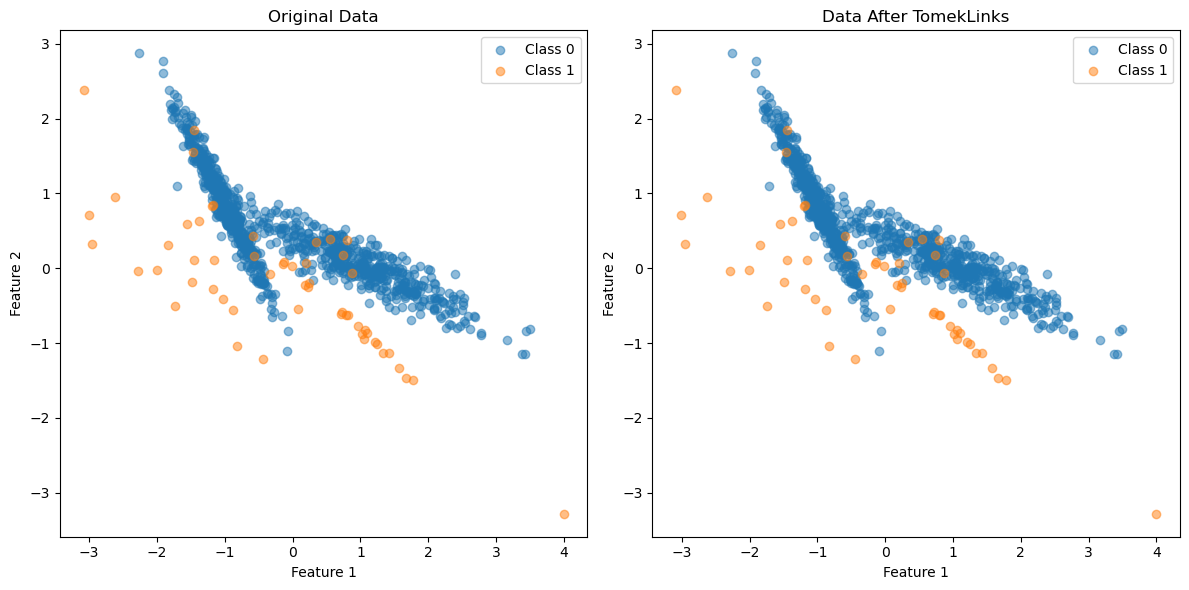

In [19]:
tomek = TomekLinks(sampling_strategy='auto')

# Apply TomekLinks to the dataset
X_tomek, y_tomek = tomek.fit_resample(X, y)

# Visualize the data before and after TomekLinks
plt.figure(figsize=(12, 6))

# Plot original data
plt.subplot(1, 2, 1)
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Class 0', alpha=0.5)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Class 1', alpha=0.5)
plt.title('Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Plot data after TomekLinks
plt.subplot(1, 2, 2)
plt.scatter(X_tomek[y_tomek == 0][:, 0], X_tomek[y_tomek == 0][:, 1], label='Class 0', alpha=0.5)
plt.scatter(X_tomek[y_tomek == 1][:, 0], X_tomek[y_tomek == 1][:, 1], label='Class 1', alpha=0.5)
plt.title('Data After TomekLinks')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.tight_layout()

In [20]:
t = [(d) for d in y_tomek if d==0]
s = [(d) for d in y_tomek if d==1]
print('After TomekLinks: ')
print('Samples in class 0: ',len(t))
print('Samples in class 1: ',len(s))

After TomekLinks: 
Samples in class 0:  937
Samples in class 1:  55


### SMOTE-Tomek

- SMOTE-Tomek is a combination of two resampling techniques: Synthetic Minority Over-sampling Technique (SMOTE) and Tomek links.
- This hybrid approach aims to improve the performance of machine learning models on imbalanced datasets by first oversampling the minority class using SMOTE and then removing ambiguous instances using Tomek links.

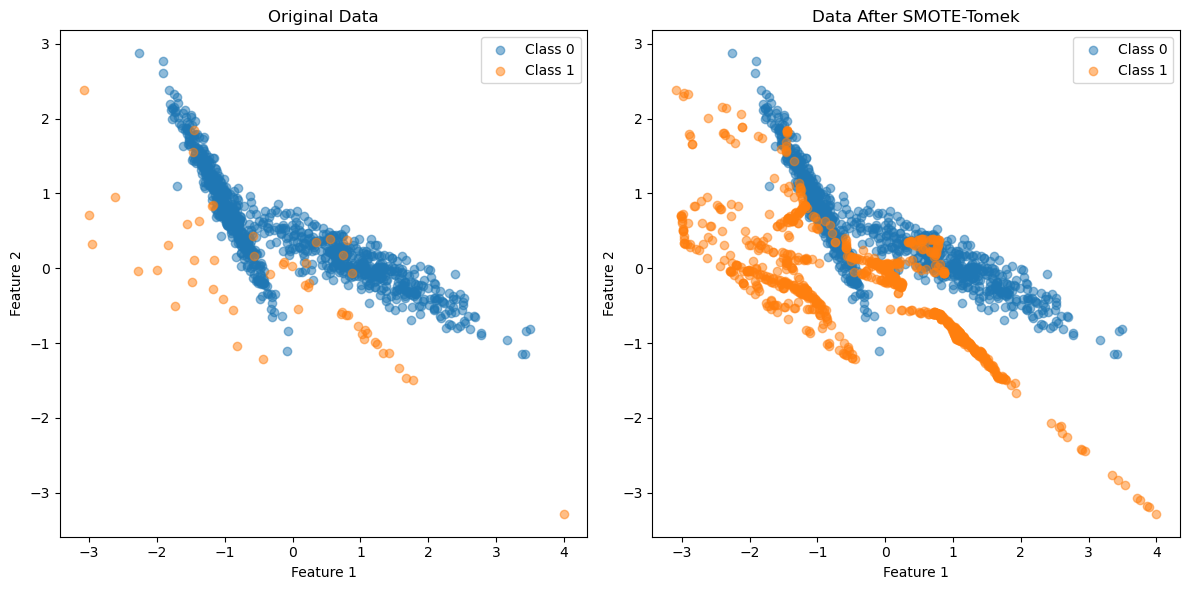

In [24]:
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(sampling_strategy='auto')

# Apply SMOTE-Tomek to the dataset
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

# Visualize the data before and after SMOTE-Tomek
plt.figure(figsize=(12, 6))

# Plot original data
plt.subplot(1, 2, 1)
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Class 0', alpha=0.5)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Class 1', alpha=0.5)
plt.title('Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Plot data after SMOTE-Tomek
plt.subplot(1, 2, 2)
plt.scatter(X_resampled[y_resampled == 0][:, 0], X_resampled[y_resampled == 0][:, 1], label='Class 0', alpha=0.5)
plt.scatter(X_resampled[y_resampled == 1][:, 0], X_resampled[y_resampled == 1][:, 1], label='Class 1', alpha=0.5)
plt.title('Data After SMOTE-Tomek')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.tight_layout()

In [25]:
t = [(d) for d in y_resampled if d==0]
s = [(d) for d in y_resampled if d==1]
print('After SMOTE-Tomek: ')
print('Samples in class 0: ',len(t))
print('Samples in class 1: ',len(s))

After SMOTE-Tomek: 
Samples in class 0:  905
Samples in class 1:  905


In [26]:
X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Train logistic regression model
log_reg_resampled = LogisticRegression()
log_reg_resampled.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred_resampled = log_reg_resampled.predict(X_test_resampled)

# Calculate evaluation metrics
precision_resampled = precision_score(y_test_resampled, y_pred_resampled)
recall_resampled = recall_score(y_test_resampled, y_pred_resampled)
f1_resampled = f1_score(y_test_resampled, y_pred_resampled)
roc_auc_resampled = roc_auc_score(y_test_resampled, y_pred_resampled)

# Print the evaluation metrics
print("Precision (SMOTE-Tomek):", precision_resampled)
print("Recall (SMOTE-Tomek):", recall_resampled)
print("F1 Score (SMOTE-Tomek):", f1_resampled)
print("ROC AUC Score (SMOTE-Tomek):", roc_auc_resampled)

Precision (SMOTE-Tomek): 0.861271676300578
Recall (SMOTE-Tomek): 0.8465909090909091
F1 Score (SMOTE-Tomek): 0.8538681948424068
ROC AUC Score (SMOTE-Tomek): 0.8587793255131965
